In [ ]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [ ]:
df = pd.read_csv("../data/raw/vietnam_weather_2023_complete.csv")

# Encode

In [ ]:
col = df.dtypes == 'object'
col = df.columns[col]
col

Index(['city', 'sunrise', 'sunset'], dtype='object')

In [ ]:
df['city']

0          Hanoi
1          Hanoi
2          Hanoi
3          Hanoi
4          Hanoi
          ...   
13147    Long An
13148    Long An
13149    Long An
13150    Long An
13151    Long An
Name: city, Length: 13152, dtype: object

## Drop city vì có tọa độ

In [ ]:
# from sklearn.preprocessing import OneHotEncoder
# # encoder = OneHotEncoder(sparse_output=False)
# # data_city = pd.DataFrame(df['city'])
# # encode_data = encoder.fit_transform(data_city)
# # df_encode = pd.DataFrame(encode_data, columns=encoder.get_feature_names_out(['city']))
# # df_encode = pd.concat([df, df_encode], axis=1)
# # df_encode

,city,latitude,longitude,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,rain_sum,precipitation_hours,weather_code,...,city_Dong Nai,city_Hanoi,city_Ho Chi Minh,city_Hue,city_Khanh Hoa,city_Long An,city_Quang Nam,city_Quang Ninh,city_Thai Nguyen,city_Vinh Phuc
0,Hanoi,21.0278,105.8342,2022-01-01,20.7,13.9,16.9,0.0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Hanoi,21.0278,105.8342,2022-01-02,21.6,14.9,17.2,0.0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Hanoi,21.0278,105.8342,2022-01-03,21.8,12.9,17.6,0.0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Hanoi,21.0278,105.8342,2022-01-04,23.9,13.4,18.2,0.0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Hanoi,21.0278,105.8342,2022-01-05,24.0,17.0,19.8,0.0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13147,Long An,10.5336,106.4110,2024-12-27,30.7,23.4,26.1,17.1,5.0,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
13148,Long An,10.5336,106.4110,2024-12-28,29.9,23.0,25.6,6.3,7.0,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
13149,Long An,10.5336,106.4110,2024-12-29,29.9,21.5,25.4,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
13150,Long An,10.5336,106.4110,2024-12-30,30.3,20.4,25.3,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
df_encode['sunrise'] = pd.to_datetime(df_encode['sunrise']).dt.time
df_encode['sunset'] = pd.to_datetime(df_encode['sunset']).dt.time
df_encode

,city,latitude,longitude,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,rain_sum,precipitation_hours,weather_code,...,city_Dong Nai,city_Hanoi,city_Ho Chi Minh,city_Hue,city_Khanh Hoa,city_Long An,city_Quang Nam,city_Quang Ninh,city_Thai Nguyen,city_Vinh Phuc
0,Hanoi,21.0278,105.8342,2022-01-01,20.7,13.9,16.9,0.0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Hanoi,21.0278,105.8342,2022-01-02,21.6,14.9,17.2,0.0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Hanoi,21.0278,105.8342,2022-01-03,21.8,12.9,17.6,0.0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Hanoi,21.0278,105.8342,2022-01-04,23.9,13.4,18.2,0.0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Hanoi,21.0278,105.8342,2022-01-05,24.0,17.0,19.8,0.0,0.0,0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13147,Long An,10.5336,106.4110,2024-12-27,30.7,23.4,26.1,17.1,5.0,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
13148,Long An,10.5336,106.4110,2024-12-28,29.9,23.0,25.6,6.3,7.0,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
13149,Long An,10.5336,106.4110,2024-12-29,29.9,21.5,25.4,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
13150,Long An,10.5336,106.4110,2024-12-30,30.3,20.4,25.3,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
col_int = df_encode.dtypes == 'int64'
col_int = df_encode.columns[col_int]
df_encode[col_int] = df_encode[col_int].astype('float64')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
z_scaler = StandardScaler()
df_col = df_encode.copy()
df_col = df_col.drop(columns=['latitude', 'longitude', 'weather_code'])

col_nums = df_encode.dtypes == 'float64'
col_nums.loc[['latitude', 'longitude', 'weather_code']] = False
col_nums = df_encode.columns[col_nums]
col_nums = col_nums[:-12]

df_scaler = df_encode.copy()
df_scaler[col_nums] = z_scaler.fit_transform(df_scaler[col_nums])

col_nums


Index(['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'rain_sum', 'precipitation_hours', 'sunshine_duration',
       'daylight_duration', 'wind_speed_10m_max', 'wind_speed_10m_mean',
       'wind_gusts_10m_max', 'wind_direction_10m_dominant',
       'shortwave_radiation_sum', 'relative_humidity_2m_max',
       'relative_humidity_2m_min', 'relative_humidity_2m_mean',
       'dewpoint_2m_max', 'dewpoint_2m_min', 'dewpoint_2m_mean',
       'surface_pressure_mean', 'cloudcover_mean'],
      dtype='object')

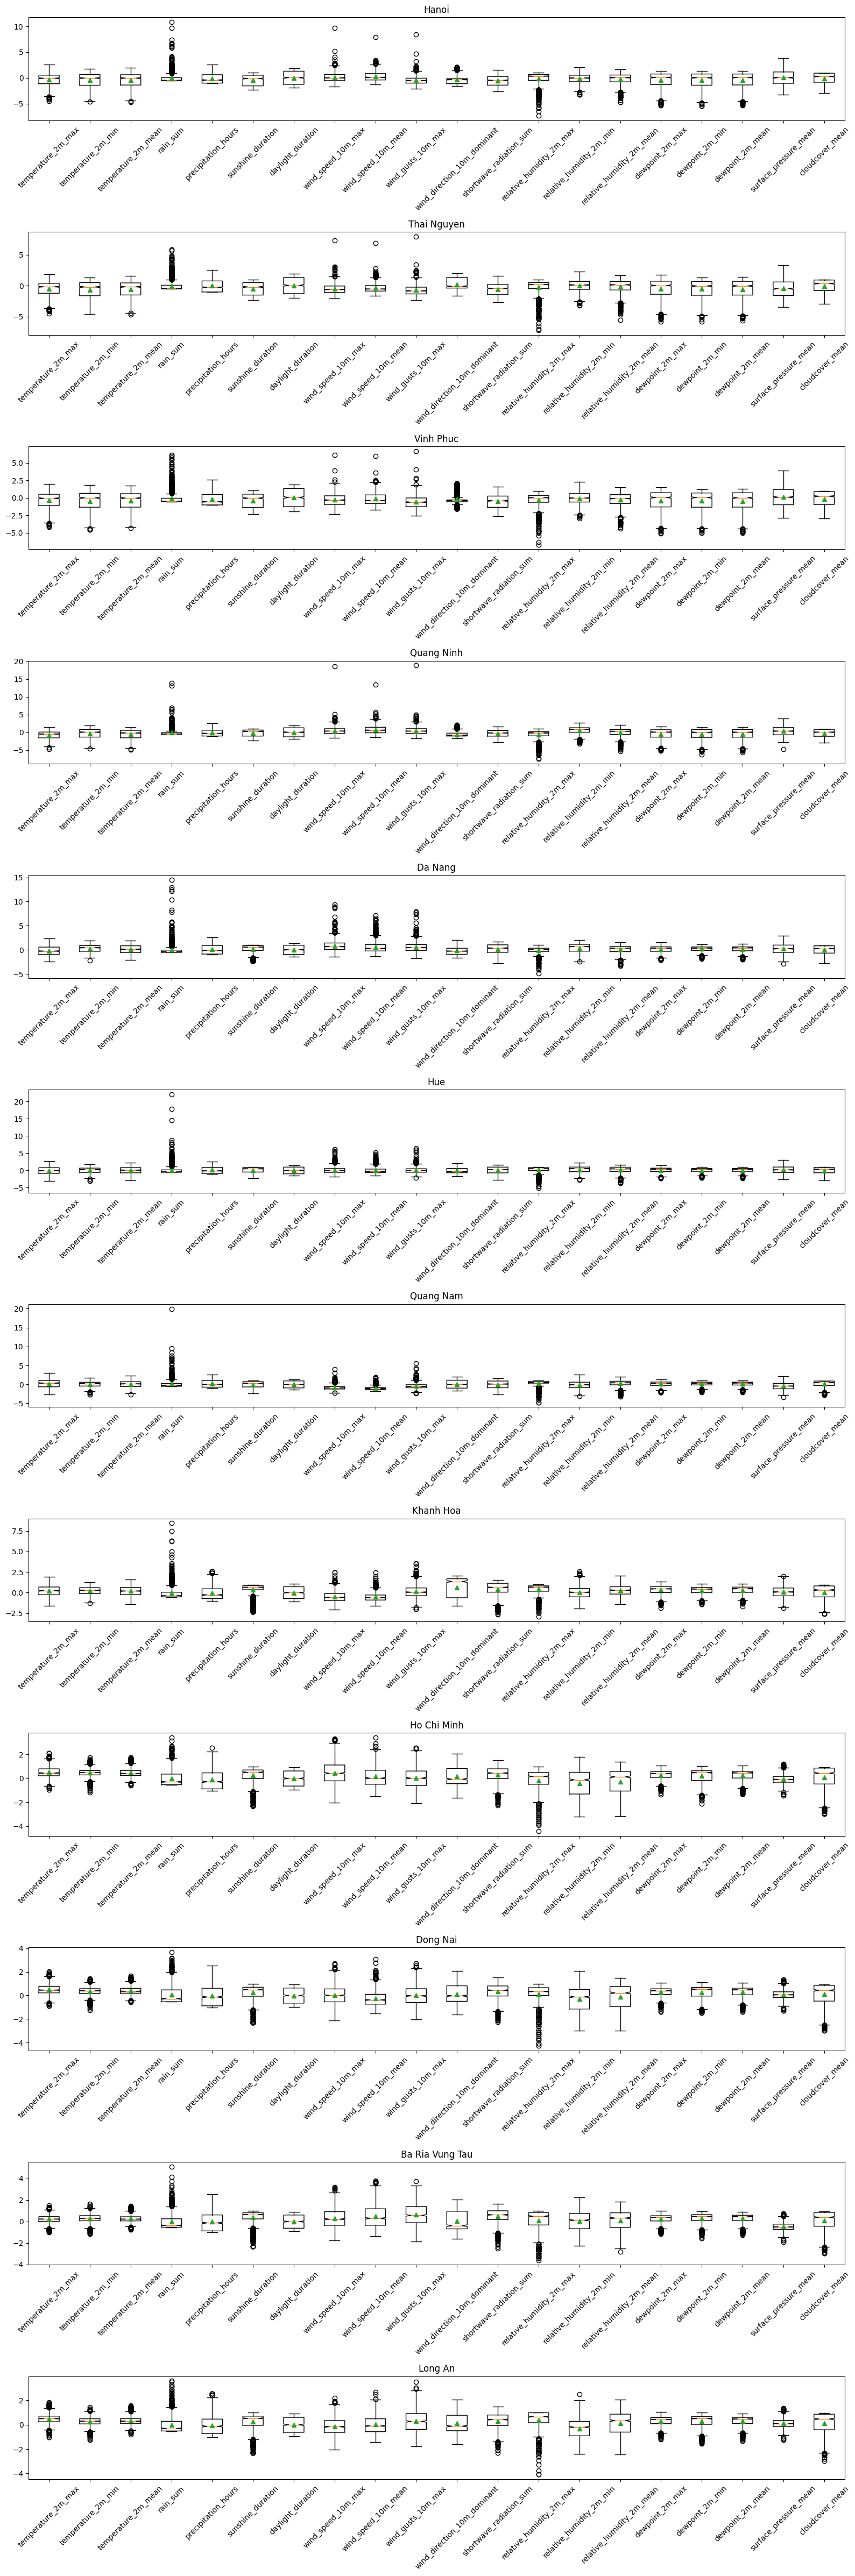

In [ ]:
plt.figure(figsize=(16, 48))
for index, city in enumerate(cities):
    plt.subplot(len(cities), 1, index + 1)
    data = df_scaler[df_scaler['city'] == city][col_nums]
    plt.boxplot([data[c] for c in col_nums], tick_labels=col_nums, showmeans=True, notch=True)
    plt.title(city)
    plt.xticks(rotation=45)
    plt.tight_layout()

### Handle Outlier

In [ ]:
outlier = ['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
           'rain_sum', 'precipitation_hours', 'sunshine_duration',
           'wind_speed_10m_max', 'wind_speed_10m_mean', 'wind_gusts_10m_max', 'shortwave_radiation_sum',
           'relative_humidity_2m_max', 'relative_humidity_2m_min', 'relative_humidity_2m_mean',
           'dewpoint_2m_max', 'dewpoint_2m_min', 'dewpoint_2m_mean',
           'surface_pressure_mean', 'cloudcover_mean']


for col in outlier:
    Q1 = df_encode[col].quantile(0.25)
    Q3 = df_encode[col].quantile(0.75)
    IQR = Q3 - Q1
    mask_below_q1 = df_encode[col] < (Q1 - 1.5 * IQR)
    mask_above_q3 = df_encode[col] > (Q3 + 1.5 * IQR)
    df_encode.loc[mask_below_q1, col] = Q1 - 1.5 * IQR
    df_encode.loc[mask_above_q3, col] = Q3 + 1.5 * IQR

df_encode[col_nums] = scaler.fit_transform(df_encode[col_nums])

for index, city in enumerate(cities):
    df_city = df_encode['city'] == city
    df_encode.loc[df_city, outlier] = df_encode.loc[df_city, outlier].rolling(window=7, min_periods=1).mean()

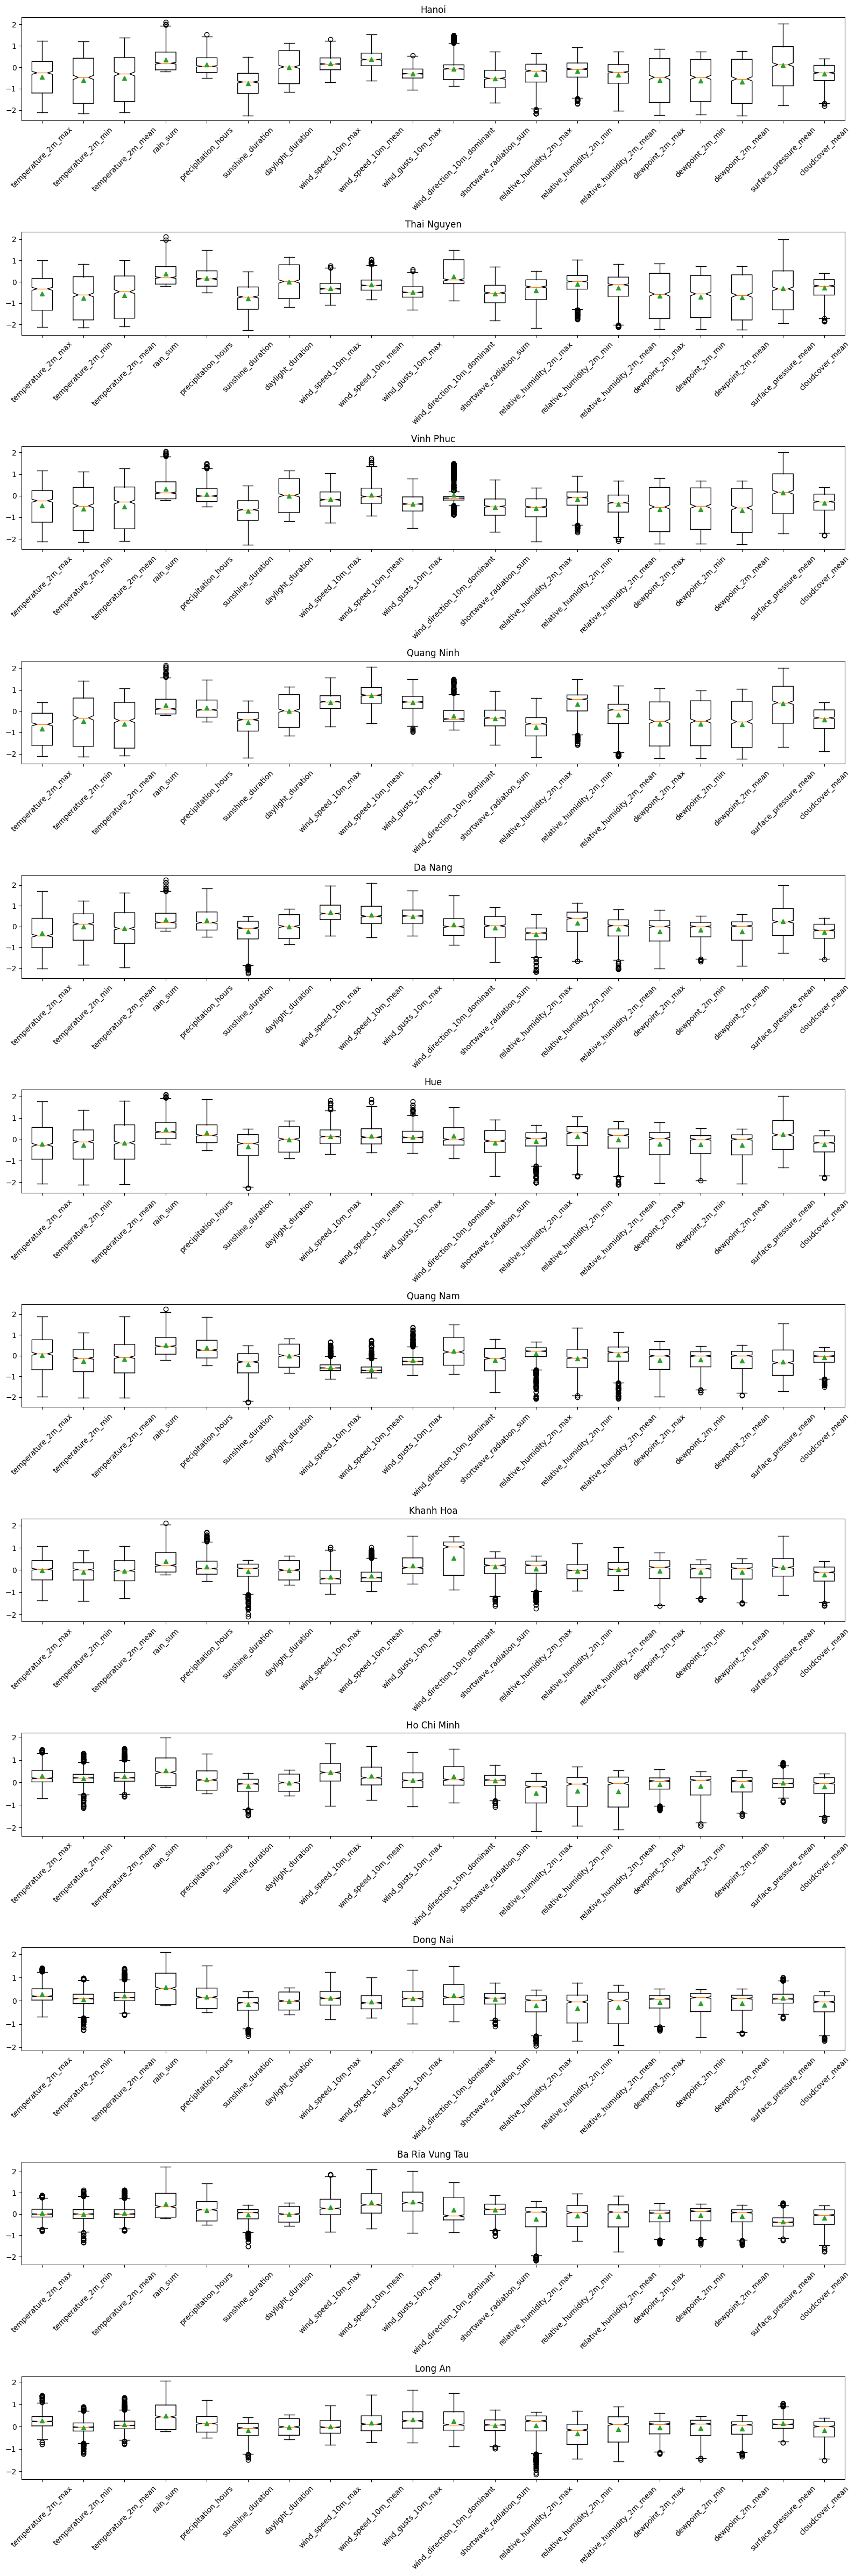

In [ ]:
plt.figure(figsize=(16, 48))
for index, city in enumerate(cities):
    plt.subplot(len(cities), 1, index + 1)
    data = df_encode[df_encode['city'] == city][col_nums]
    plt.boxplot([data[c] for c in col_nums], tick_labels=col_nums, showmeans=True, notch=True)
    plt.title(city)
    plt.xticks(rotation=45)
    plt.tight_layout()

### Feature Extraction

In [ ]:
# Thay đổi các giá trị date thành ngày tháng năm
df_feature = df_encode.copy()
df_feature['year'] = df_feature['date'].dt.year
df_feature['month'] = df_feature['date'].dt.month
df_feature['day'] = df_feature['date'].dt.day
df_feature['dayofweek'] = df_feature['date'].dt.dayofweek
df_feature['quarter'] = df_feature['date'].dt.quarter
df_feature['dayinmonth'] = df_feature['date'].dt.days_in_month
# df_feature = df_feature.drop(columns=['date'])

In [ ]:
# Kỹ thuật Cyclical Feature Encoding
month_max = 12
week_day_max = 7
df_feature['month_sin'] = np.sin(2 * np.pi * df_feature['month'] / month_max)
df_feature['month_cos'] = np.cos(2 * np.pi * df_feature['month'] / month_max)
df_feature['day_sin'] = np.sin(2 * np.pi * df_feature['day'] / df_feature['dayinmonth'])
df_feature['day_cos'] = np.cos(2 * np.pi * df_feature['day'] / df_feature['dayinmonth'])
df_feature['dayofweek_sin'] = np.sin(2 * np.pi * df_feature['dayofweek'] / week_day_max)
df_feature['dayofweek_cos'] = np.cos(2 * np.pi * df_feature['dayofweek'] / week_day_max)
df_feature['quarter_sin'] = np.sin(2 * np.pi * df_feature['quarter'] / 4)
df_feature['quarter_cos'] = np.cos(2 * np.pi * df_feature['quarter'] / 4)

In [ ]:
df_cycling = df_feature.drop(columns=['month', 'day', 'dayofweek', 'quarter', 'dayinmonth'])
df_cycling

,city,latitude,longitude,date,temperature_2m_max,temperature_2m_min,temperature_2m_mean,rain_sum,precipitation_hours,weather_code,...,city_Vinh Phuc,year,month_sin,month_cos,day_sin,day_cos,dayofweek_sin,dayofweek_cos,quarter_sin,quarter_cos
0,Hanoi,21.0278,105.8342,2022-01-01,-2.106383,-2.147059,-2.100000,-0.207317,-0.500000,0.0,...,0.0,2022,5.000000e-01,0.866025,2.012985e-01,0.979530,-0.974928,-0.222521,1.000000e+00,6.123234e-17
1,Hanoi,21.0278,105.8342,2022-01-02,-2.010638,-2.147059,-2.100000,-0.207317,-0.500000,0.0,...,0.0,2022,5.000000e-01,0.866025,3.943559e-01,0.918958,-0.781831,0.623490,1.000000e+00,6.123234e-17
2,Hanoi,21.0278,105.8342,2022-01-03,-1.964539,-2.147059,-2.100000,-0.207317,-0.500000,0.0,...,0.0,2022,5.000000e-01,0.866025,5.712682e-01,0.820763,0.000000,1.000000,1.000000e+00,6.123234e-17
3,Hanoi,21.0278,105.8342,2022-01-04,-1.829787,-2.147059,-2.100000,-0.207317,-0.500000,0.0,...,0.0,2022,5.000000e-01,0.866025,7.247928e-01,0.688967,0.781831,0.623490,1.000000e+00,6.123234e-17
4,Hanoi,21.0278,105.8342,2022-01-05,-1.744681,-2.123529,-2.068571,-0.207317,-0.500000,0.0,...,0.0,2022,5.000000e-01,0.866025,8.486443e-01,0.528964,0.974928,-0.222521,1.000000e+00,6.123234e-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13147,Long An,10.5336,106.4110,2024-12-27,-0.246201,-0.621849,-0.355102,0.179443,-0.228571,2.0,...,0.0,2024,-2.449294e-16,1.000000,-7.247928e-01,0.688967,-0.433884,-0.900969,-2.449294e-16,1.000000e+00
13148,Long An,10.5336,106.4110,2024-12-28,-0.234043,-0.491597,-0.318367,0.289199,-0.128571,2.0,...,0.0,2024,-2.449294e-16,1.000000,-5.712682e-01,0.820763,-0.974928,-0.222521,-2.449294e-16,1.000000e+00
13149,Long An,10.5336,106.4110,2024-12-29,-0.139818,-0.432773,-0.232653,0.289199,-0.128571,0.0,...,0.0,2024,-2.449294e-16,1.000000,-3.943559e-01,0.918958,-0.781831,0.623490,-2.449294e-16,1.000000e+00
13150,Long An,10.5336,106.4110,2024-12-30,-0.133739,-0.386555,-0.204082,0.289199,-0.128571,0.0,...,0.0,2024,-2.449294e-16,1.000000,-2.012985e-01,0.979530,0.000000,1.000000,-2.449294e-16,1.000000e+00


## Ở đây lựa chọn z-score dựa vào lựa chọn mô hình 
- Với mô hình hồi quy như SVM, NN hoạt động tốt với PP chuẩn 
- Các mô hình tree-based ko bị ảnh hưởng thì ko cần 

In [ ]:

scaler = StandardScaler()
df_cycling[col_nums] = scaler.fit_transform(df_cycling[col_nums])

In [ ]:
data_vungmien['North'] = df_feature[df_feature['city'].isin(north_cities)]
data_vungmien['Central'] = df_feature[df_feature['city'].isin(central_cities)]
data_vungmien['South'] = df_feature[df_feature['city'].isin(south_cities)]

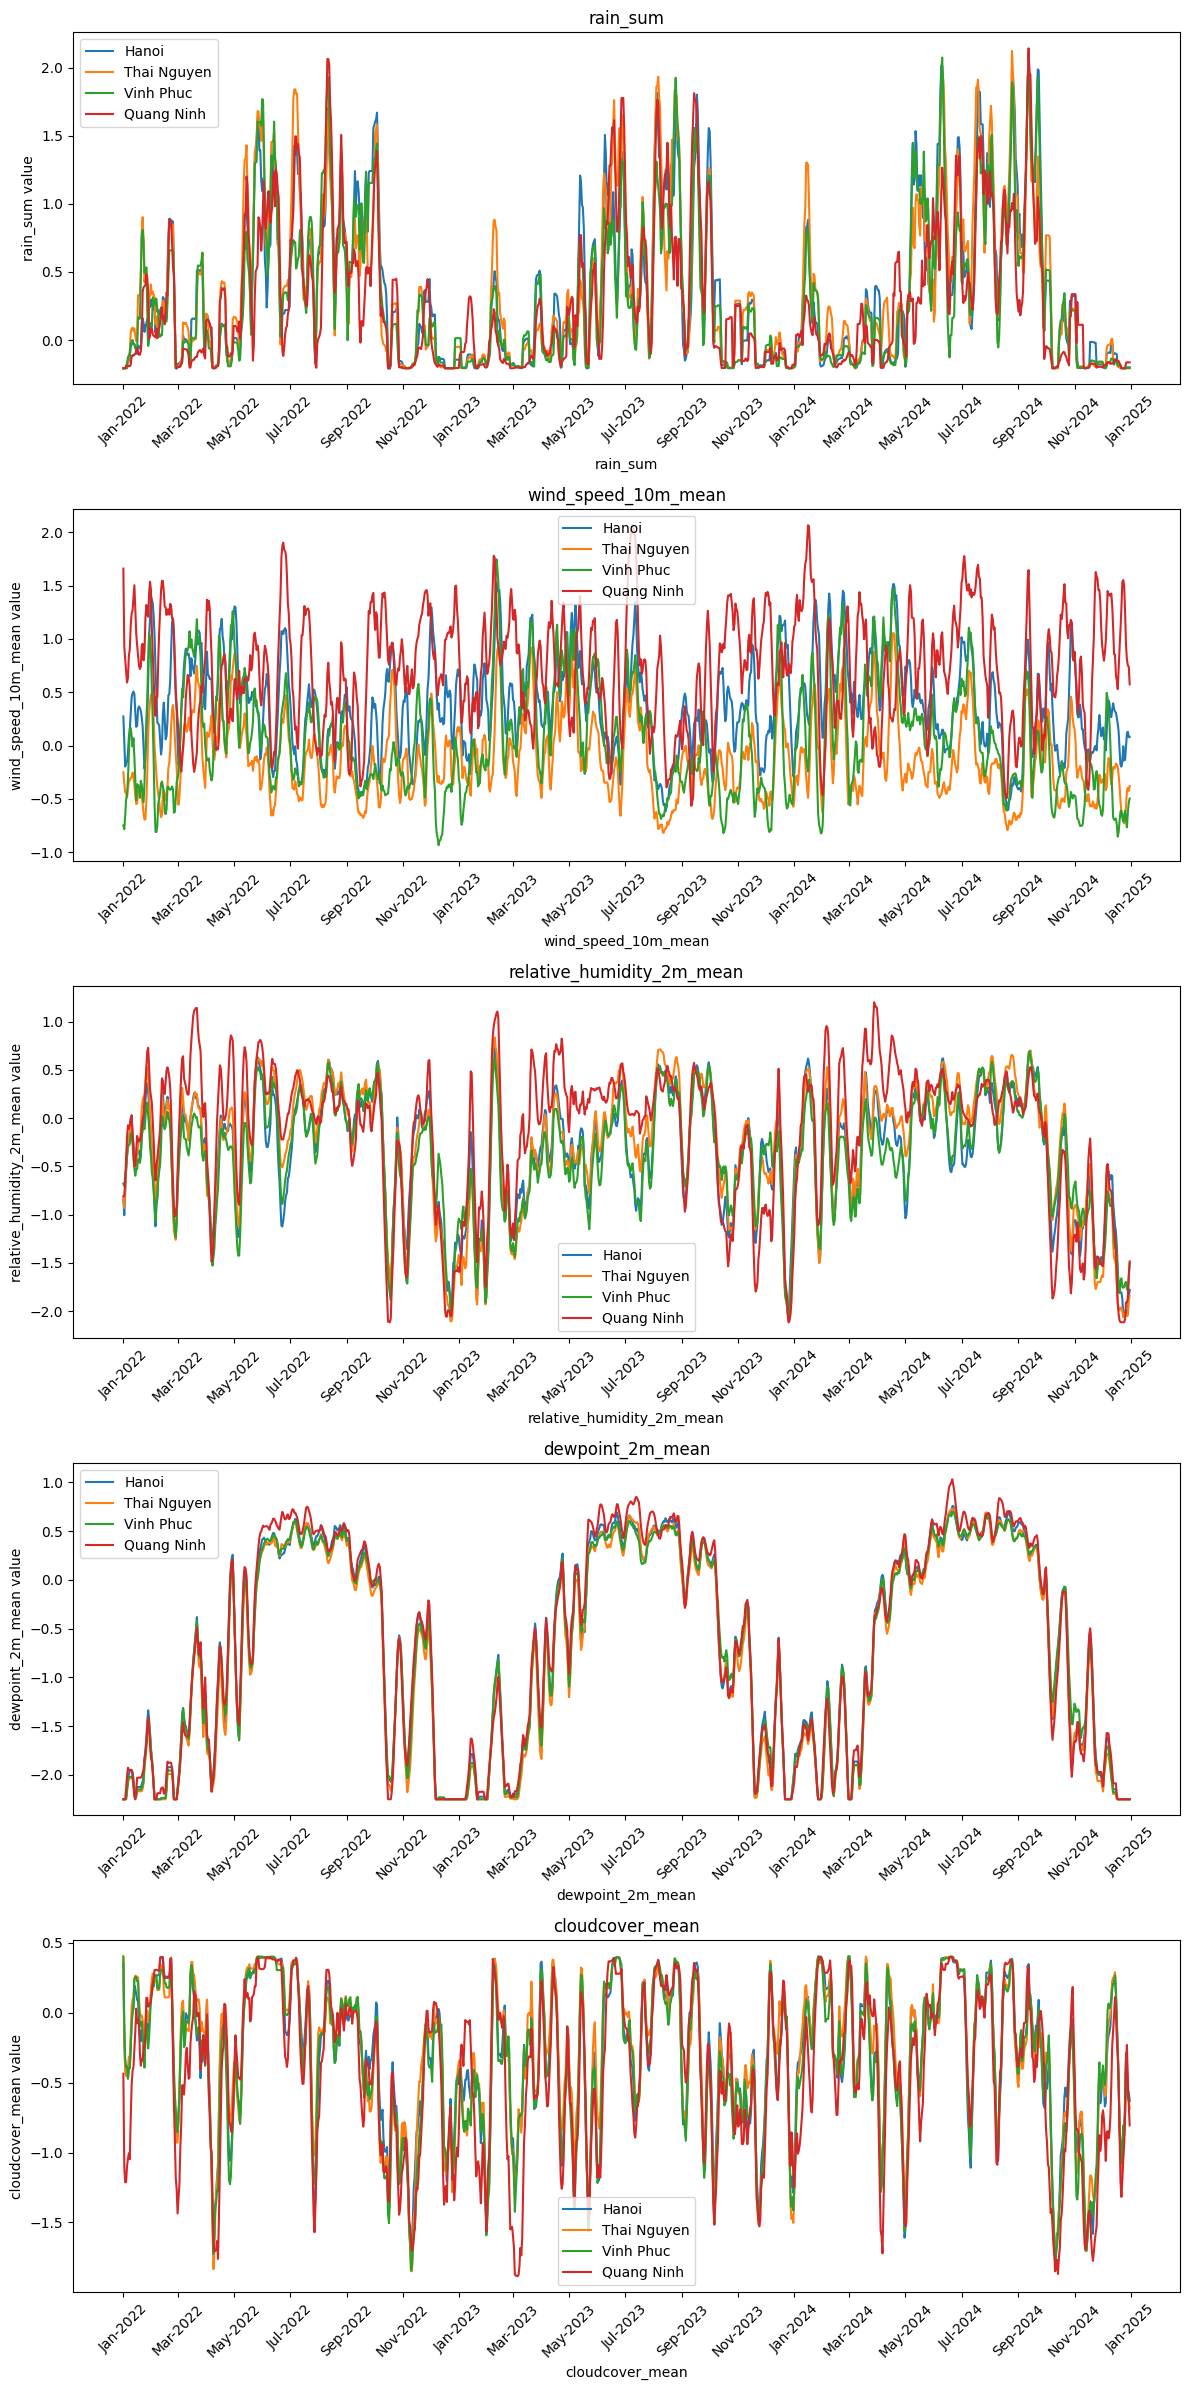

In [ ]:
plot_region_data("North", north_cities, feature)


In [ ]:
col_nums

Index(['temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
       'rain_sum', 'precipitation_hours', 'sunshine_duration',
       'daylight_duration', 'wind_speed_10m_max', 'wind_speed_10m_mean',
       'wind_gusts_10m_max', 'wind_direction_10m_dominant',
       'shortwave_radiation_sum', 'relative_humidity_2m_max',
       'relative_humidity_2m_min', 'relative_humidity_2m_mean',
       'dewpoint_2m_max', 'dewpoint_2m_min', 'dewpoint_2m_mean',
       'surface_pressure_mean', 'cloudcover_mean'],
      dtype='object')

C:\Users\buiti\AppData\Local\Temp\ipykernel_22620\1908113111.py:5: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\buiti\AppData\Local\Temp\ipykernel_22620\1908113111.py:5: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\buiti\AppData\Local\Temp\ipykernel_22620\1908113111.py:5: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\buiti\AppData\Local\Temp\ipykernel_22620\1908113111.py:5: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
C:\Users\buiti\AppData\Local\Temp\ipykernel_22620\1908113111.py:5: UserWarning: Tight layout not applied. tight_layout cannot make Axes height s

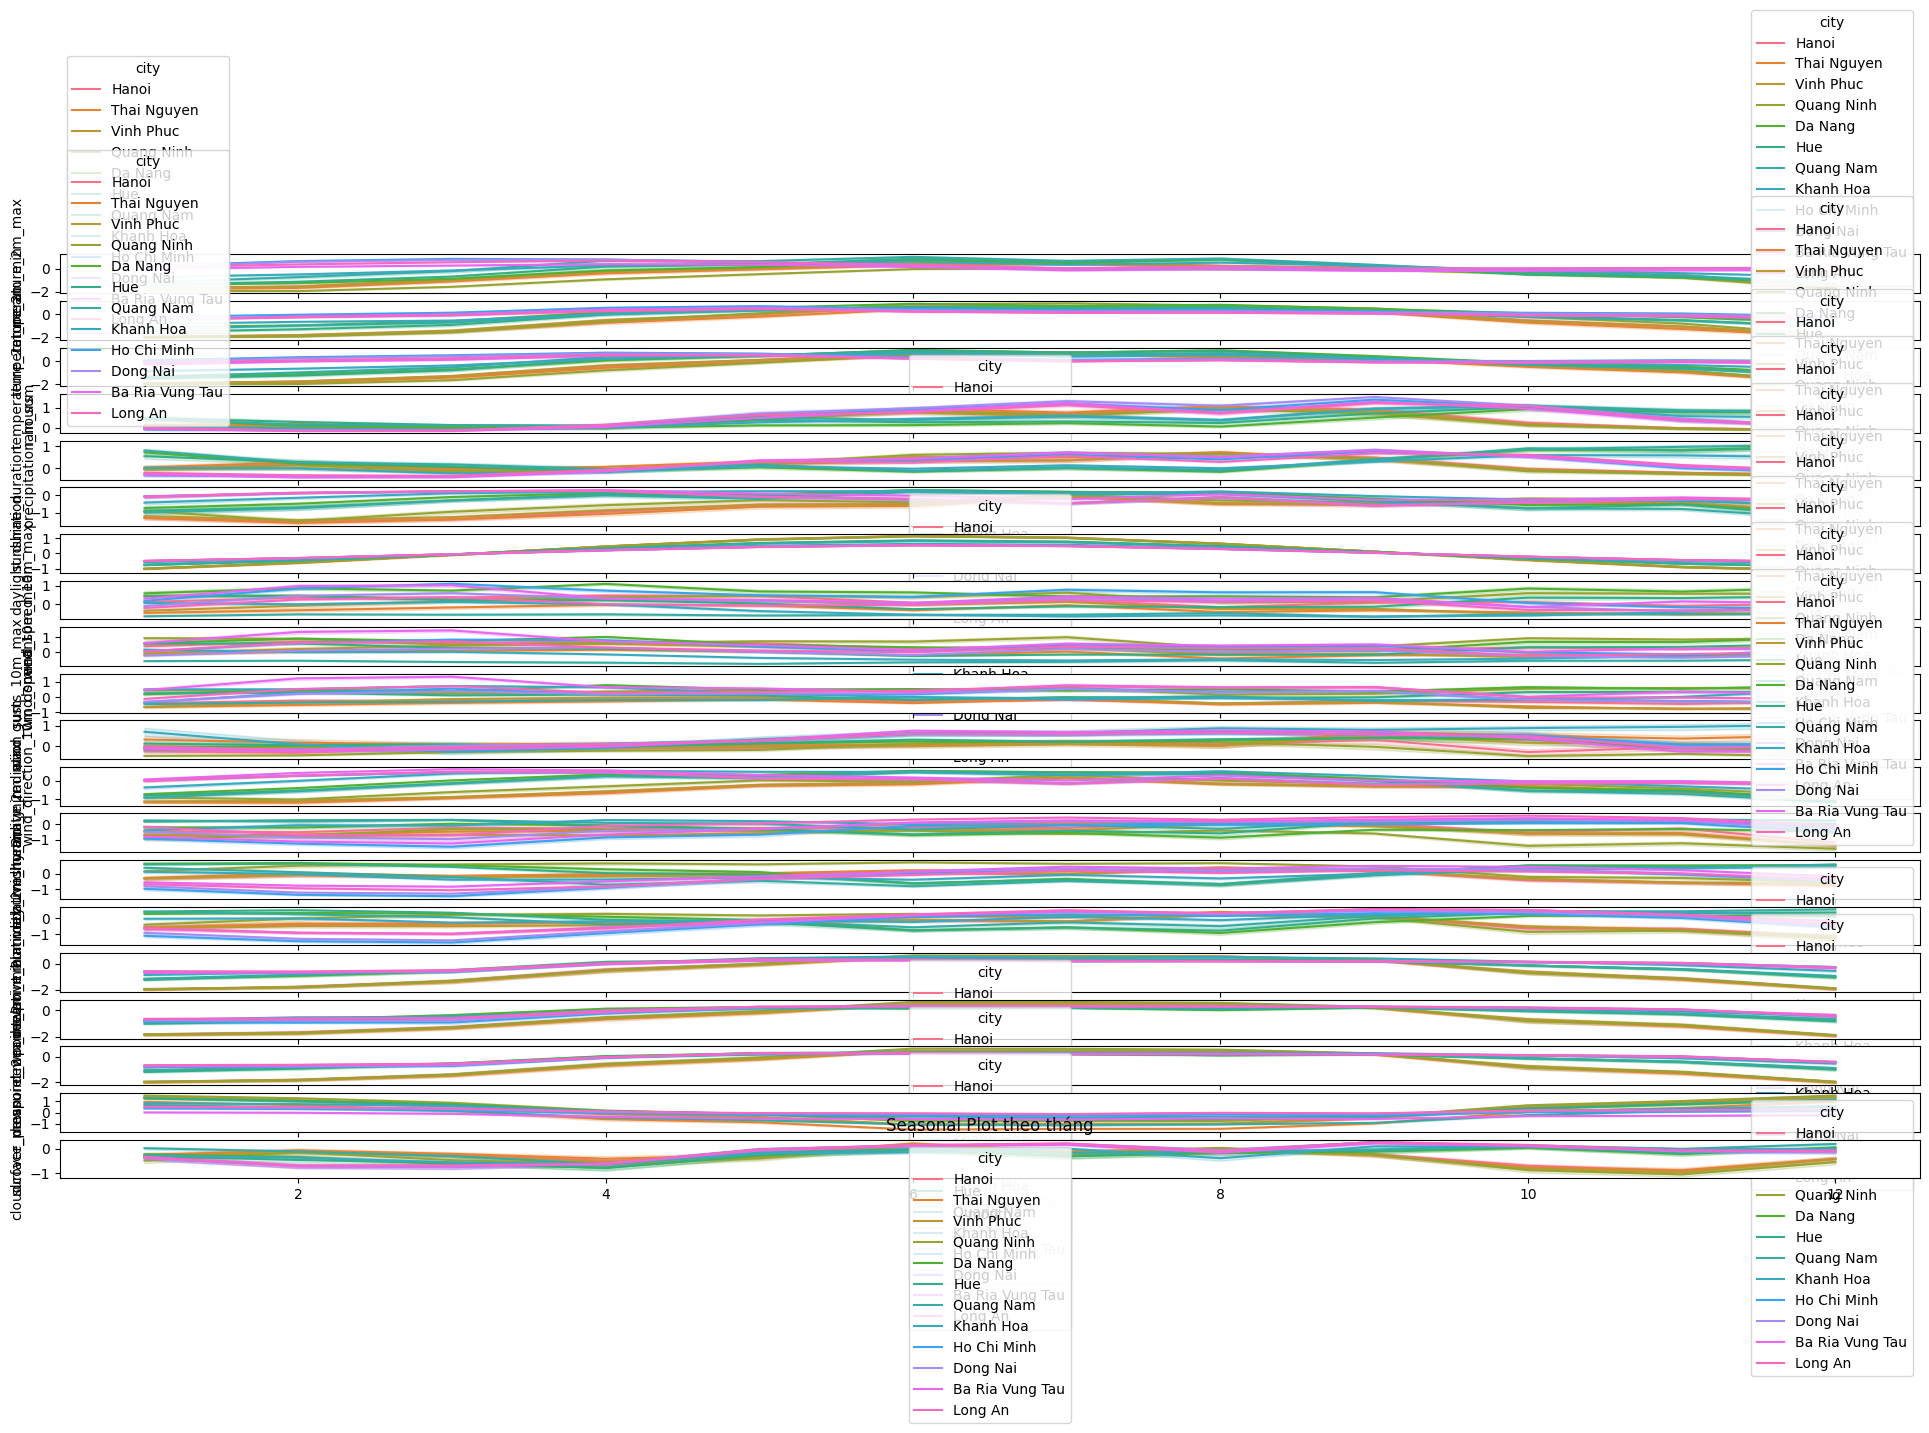

In [ ]:
plt.figure(figsize=(24, 12))
for index, col in enumerate(col_nums):
    plt.subplot(len(col_nums), 1, index + 1)
    sns.lineplot(data=df_feature, x='month', y=col, hue='city')
    plt.tight_layout()
plt.title("Seasonal Plot theo tháng")
plt.show()

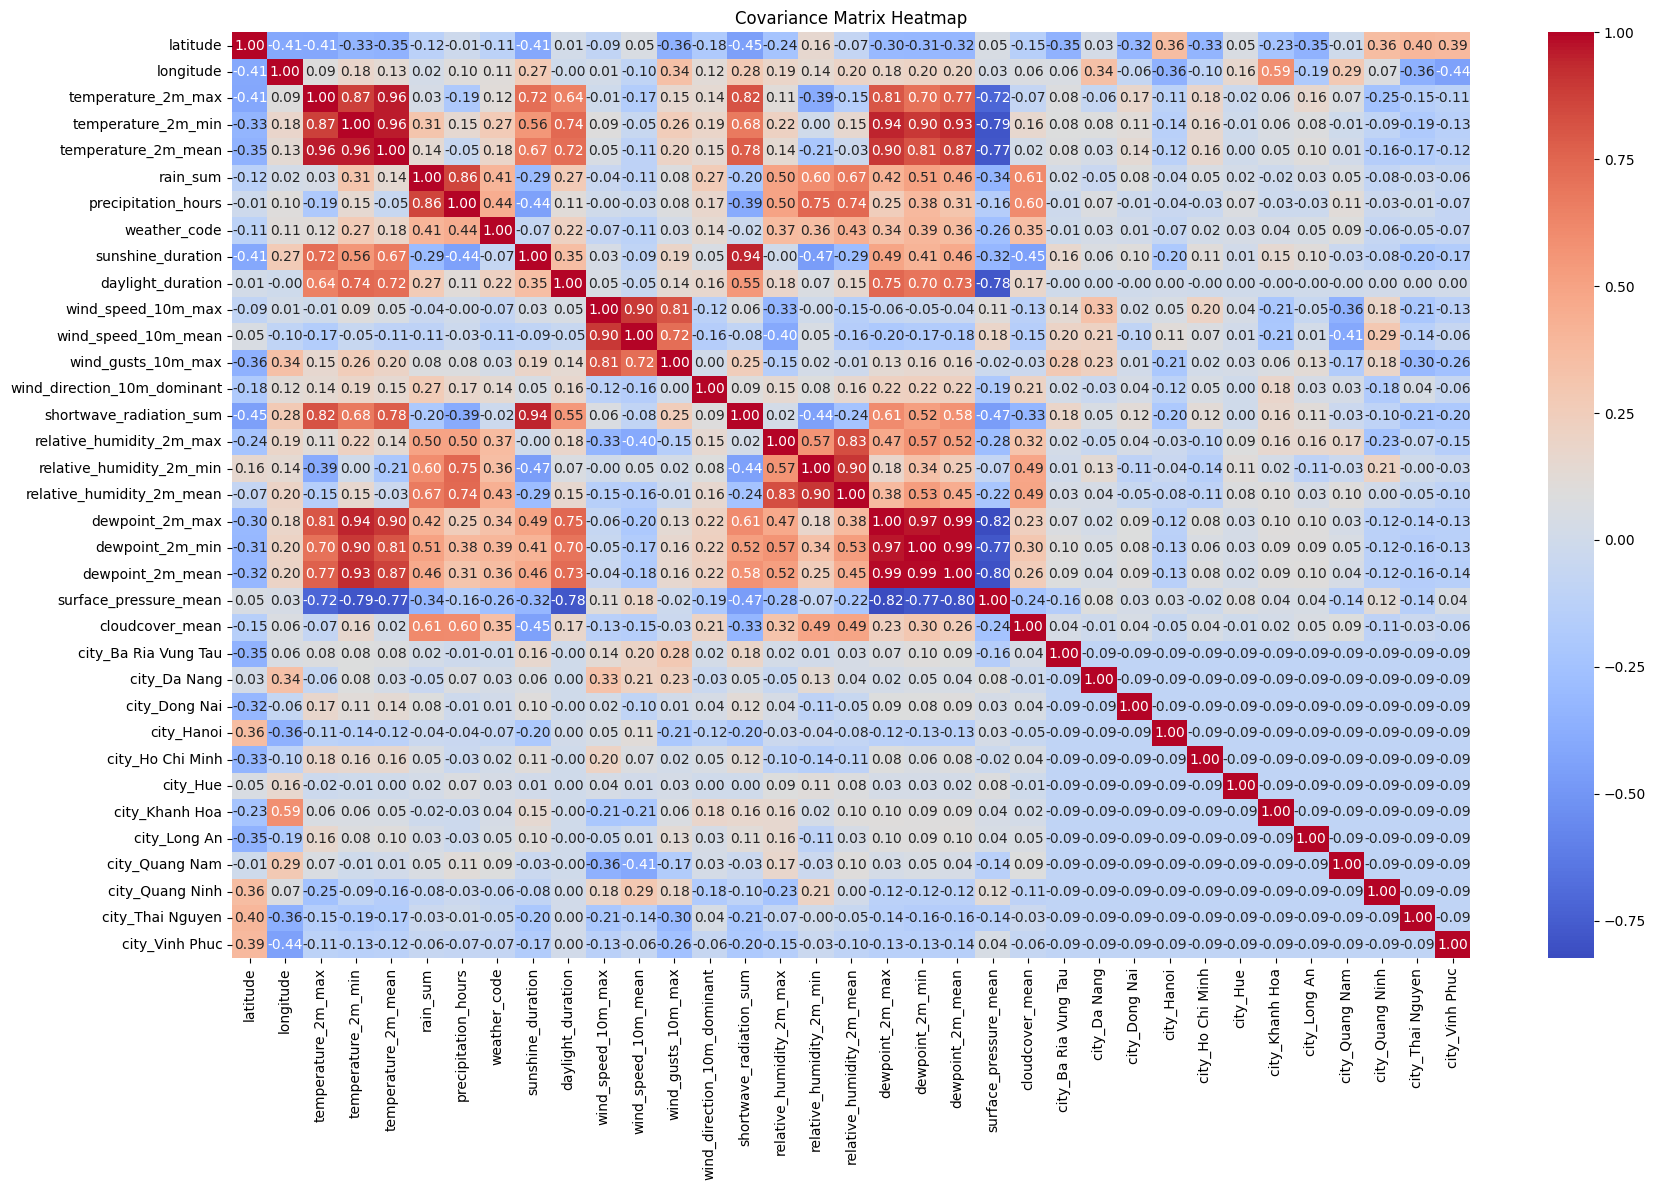

In [ ]:
numeric_cols = df_encode.select_dtypes(include='number').columns
cov_matrix = df_encode[numeric_cols].corr()

plt.figure(figsize=(18, 12))
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Covariance Matrix Heatmap")
plt.tight_layout()
plt.show()
